In [46]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ID = "fyxical-poc"
DATASET    = "fyxical_poc"
client     = bigquery.Client(project=PROJECT_ID)

patients  = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_intake`").to_dataframe()
exercises = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.exercises`").to_dataframe()

print(f"Patients  : {len(patients)}")
print(f"Exercises : {len(exercises)}")

Patients  : 500
Exercises : 116


In [47]:
# Acronym reference

ACRONYMS_CLINICAL = {
    "OSW"  : "Oswestry Disability Index — validated clinical scale measuring functional "
              "disability due to low back pain (0-100%). Thresholds: Minimal 0-20%, "
              "Moderate 21-40%, Severe 41-60%, Crippled 61-80%, Bed-bound 81-100%.",
    "VAS"  : "Visual Analogue Scale — pain self-report score (0=no pain, 10=worst pain). "
              "Used here as pain_severity_score_0_10.",
    "POC"  : "Proof of Concept — this project stage. Not validated for clinical use.",
    "MVP"  : "Minimum Viable Product — the scope of the current decision tree.",
    "HITL" : "Human-in-the-Loop — planned validation protocol where a licensed PT "
              "independently labels edge cases to provide clinician-derived ground truth.",
}

ACRONYMS_EXERCISES = {
    "BHF" : "Bilateral Hip Flexion / Low Back Flexion Stretch",
    "BR"  : "Bracing",
    "BRG" : "Bridging",
    "CHP" : "Child's Pose",
    "HF"  : "Hip Flexion",
    "HSE" : "Hip / Shoulder Extension",
    "LFT" : "Lift Training",
    "LME" : "Lumbar Extension Progression",
    "LTR" : "Lumbar Trunk Rotation",
    "LTS" : "Lateral Trunk Stretch",
    "PLC" : "Pelvic Tilt",
    "PLK" : "Plank",
    "PP"  : "Paloff Press",
    "QDS" : "Quadruped Stretches",
    "RSC" : "Rows with Stable Core",
    "SGA" : "Seated Glute Activation",
    "SK"  : "Single Knee to Chest (SKTC)",
    "THE" : "Thoracic Extension",
    "THR" : "Thoracic Rotation",
}

ACRONYMS_PATHWAYS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks",
    "ACUTE_SEVERE"   : "Acute + Severe         — Pain score 7-10, Duration <2 weeks",
    "SUBACUTE"       : "Subacute               — Duration 2-12 weeks, any severity",
    "CHRONIC"        : "Chronic / High Burden  — Duration >12 weeks OR high OSW disability",
}

print("=" * 65)
print("  ACRONYM REFERENCE — Notebook 03")
print("=" * 65)

print("\n── Clinical & Project Terms ────────────────────────────────")
for code, desc in ACRONYMS_CLINICAL.items():
    print(f"\n  {code}")
    words = desc.split()
    line = "    "
    for word in words:
        if len(line) + len(word) + 1 > 64:
            print(line)
            line = "    " + word + " "
        else:
            line += word + " "
    print(line.rstrip())

print("\n── Pathway Codes ───────────────────────────────────────────")
for code, desc in ACRONYMS_PATHWAYS.items():
    print(f"  {code:<16} {desc}")

print("\n── Exercise Group Codes (all 19) ───────────────────────────")
for code, desc in ACRONYMS_EXERCISES.items():
    print(f"  {code:<5} {desc}")

print("\n" + "=" * 65)

  ACRONYM REFERENCE — Notebook 03

── Clinical & Project Terms ────────────────────────────────

  OSW
    Oswestry Disability Index — validated clinical scale 
    measuring functional disability due to low back pain 
    (0-100%). Thresholds: Minimal 0-20%, Moderate 21-40%, 
    Severe 41-60%, Crippled 61-80%, Bed-bound 81-100%.

  VAS
    Visual Analogue Scale — pain self-report score (0=no pain, 
    10=worst pain). Used here as pain_severity_score_0_10.

  POC
    Proof of Concept — this project stage. Not validated for 
    clinical use.

  MVP
    Minimum Viable Product — the scope of the current decision 
    tree.

  HITL
    Human-in-the-Loop — planned validation protocol where a 
    licensed PT independently labels edge cases to provide 
    clinician-derived ground truth.

── Pathway Codes ───────────────────────────────────────────
  ACUTE_MILD_MOD   Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks
  ACUTE_SEVERE     Acute + Severe         — Pain score 7-10, Dur

In [48]:
# Pathway & exercise group definitions

PATHWAY_LABELS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  (Pain 0-6, Duration <2 wks)",
    "ACUTE_SEVERE"   : "Acute + Severe         (Pain 7-10, Duration <2 wks)",
    "SUBACUTE"       : "Subacute               (Duration 2-12 wks, any severity)",
    "CHRONIC"        : "Chronic / High Burden  (Duration >12 wks OR high OSW)",
}

PATHWAY_EXERCISES = {
    "ACUTE_MILD_MOD" : ["BHF", "SK", "CHP", "LTR", "LTS", "PLC"],
    "ACUTE_SEVERE"   : ["BHF", "SK", "PLC", "SGA", "LME"],
    "SUBACUTE"       : ["PLC", "BRG", "BR", "HSE", "QDS", "THE", "THR"],
    "CHRONIC"        : ["BR", "PLK", "PP", "RSC", "LFT", "HF", "LME", "THE", "THR"],
}

# Reuse acronym dict defined in Cell 2
EXERCISE_GROUP_NAMES = ACRONYMS_EXERCISES

print("Pathway Reference:")
print("-" * 68)
for code, label in PATHWAY_LABELS.items():
    groups = ", ".join([EXERCISE_GROUP_NAMES[g] for g in PATHWAY_EXERCISES[code]])
    print(f"\n  {code}: {label}")
    print(f"  Exercises: {groups}")

Pathway Reference:
--------------------------------------------------------------------

  ACUTE_MILD_MOD: Acute + Mild/Moderate  (Pain 0-6, Duration <2 wks)
  Exercises: Bilateral Hip Flexion / Low Back Flexion Stretch, Single Knee to Chest (SKTC), Child's Pose, Lumbar Trunk Rotation, Lateral Trunk Stretch, Pelvic Tilt

  ACUTE_SEVERE: Acute + Severe         (Pain 7-10, Duration <2 wks)
  Exercises: Bilateral Hip Flexion / Low Back Flexion Stretch, Single Knee to Chest (SKTC), Pelvic Tilt, Seated Glute Activation, Lumbar Extension Progression

  SUBACUTE: Subacute               (Duration 2-12 wks, any severity)
  Exercises: Pelvic Tilt, Bridging, Bracing, Hip / Shoulder Extension, Quadruped Stretches, Thoracic Extension, Thoracic Rotation

  CHRONIC: Chronic / High Burden  (Duration >12 wks OR high OSW)
  Exercises: Bracing, Plank, Paloff Press, Rows with Stable Core, Lift Training, Hip Flexion, Lumbar Extension Progression, Thoracic Extension, Thoracic Rotation


In [49]:
# Rule-based pathway assignment

def assign_pathway(row):
    duration_weeks = row["pain_duration_weeks"]
    pain_score     = row["pain_severity_score_0_10"]
    osw_pct        = row["osw_baseline_percent_disability"]

    if duration_weeks < 2:
        duration_cat = "Acute"
    elif duration_weeks <= 12:
        duration_cat = "Subacute"
    else:
        duration_cat = "Chronic"

    if pain_score <= 3:
        severity_cat = "Mild"
    elif pain_score <= 6:
        severity_cat = "Moderate"
    else:
        severity_cat = "Severe"

    if osw_pct <= 20:
        osw_cat = "Minimal"
    elif osw_pct <= 40:
        osw_cat = "Moderate"
    elif osw_pct <= 60:
        osw_cat = "Severe"
    elif osw_pct <= 80:
        osw_cat = "Crippled"
    else:
        osw_cat = "Bed-bound"

    if duration_cat == "Acute":
        if severity_cat in ["Mild", "Moderate"] and osw_cat in ["Minimal", "Moderate"]:
            return "ACUTE_MILD_MOD"
        else:
            return "ACUTE_SEVERE"
    elif duration_cat == "Subacute":
        if osw_cat in ["Severe", "Crippled", "Bed-bound"]:
            return "CHRONIC"
        else:
            return "SUBACUTE"
    else:
        return "CHRONIC"

patients["recommended_pathway"] = patients.apply(assign_pathway, axis=1)
patients["pathway_label"]       = patients["recommended_pathway"].map(PATHWAY_LABELS)

print("Pathway assignment complete.")
print()
print(patients["recommended_pathway"].value_counts().to_string())
print()
print("Pathway by Duration × OSW category:")
print(pd.crosstab(
    patients["pain_duration_category"],
    patients["osw_baseline_disability_category"],
    values=patients["recommended_pathway"],
    aggfunc=lambda x: x.mode()[0]
).to_string())

Pathway assignment complete.

recommended_pathway
CHRONIC           296
ACUTE_SEVERE       76
SUBACUTE           67
ACUTE_MILD_MOD     61

Pathway by Duration × OSW category:
osw_baseline_disability_category      Crippled         Minimal        Moderate        Severe
pain_duration_category                                                                      
Acute                             ACUTE_SEVERE  ACUTE_MILD_MOD  ACUTE_MILD_MOD  ACUTE_SEVERE
Chronic                                CHRONIC         CHRONIC         CHRONIC       CHRONIC
Subacute                               CHRONIC        SUBACUTE        SUBACUTE       CHRONIC


In [50]:
# Rule logic summary

print("""
Rule Engine — Decision Logic Summary
--------------------------------------
Three clinical variables drive pathway assignment:

  1. pain_duration_weeks        → Acute (<2 wks) / Subacute (2-12 wks) / Chronic (>12 wks)
  2. pain_severity_score_0_10   → Mild (0-3) / Moderate (4-6) / Severe (7-10)
  3. osw_baseline_percent_disability → Minimal (0-20%) / Moderate (21-40%) /
                                       Severe (41-60%) / Crippled (61-80%) /
                                       Bed-bound (81-100%)

Pathway assignment:
  ACUTE_MILD_MOD  → Acute + Mild/Moderate pain + Minimal/Moderate OSW
                    Simple home routine, heat/ice guidance, activity modification
  ACUTE_SEVERE    → Acute + Severe pain OR Acute + high OSW
                    Same as above + 48-72hr check-in message
  SUBACUTE        → Subacute duration + Minimal/Moderate/Severe OSW
                    Progression exercises, mobility + strengthening
  CHRONIC         → Chronic duration OR Subacute + high OSW burden
                    Long-term exercise plan, education on chronic pain

Red-Flag Screening (pre-pathway):
  Patients with red-flag symptoms are directed to seek immediate
  medical evaluation. No exercise plan is generated.
  NOTE: red_flag_present column not yet in patient_intake — add before deployment.

Validation status:
  Rules are based on standard clinical LBP triage thresholds.
  Planned HITL validation: licensed PT on our team will independently
  review n=50-75 edge cases to confirm rule-clinical agreement.
  See Notebook 05 scaling roadmap for full protocol.
""")


Rule Engine — Decision Logic Summary
--------------------------------------
Three clinical variables drive pathway assignment:

  1. pain_duration_weeks        → Acute (<2 wks) / Subacute (2-12 wks) / Chronic (>12 wks)
  2. pain_severity_score_0_10   → Mild (0-3) / Moderate (4-6) / Severe (7-10)
  3. osw_baseline_percent_disability → Minimal (0-20%) / Moderate (21-40%) /
                                       Severe (41-60%) / Crippled (61-80%) /
                                       Bed-bound (81-100%)

Pathway assignment:
  ACUTE_MILD_MOD  → Acute + Mild/Moderate pain + Minimal/Moderate OSW
                    Simple home routine, heat/ice guidance, activity modification
  ACUTE_SEVERE    → Acute + Severe pain OR Acute + high OSW
                    Same as above + 48-72hr check-in message
  SUBACUTE        → Subacute duration + Minimal/Moderate/Severe OSW
                    Progression exercises, mobility + strengthening
  CHRONIC         → Chronic duration OR Subacute + high OSW

# Rule Engine - Piecewise Classification Logic

Let d = pain_duration_weeks, v = pain_severity_score_0_10, o = osw_baseline_percent_disability.

Pathway assignment:
- Acute Mild/Moderate  → d < 2 and v ≤ 6 and o ≤ 40
- Acute Severe         → d < 2 and (v > 6 or o > 40)
- Subacute             → 2 ≤ d ≤ 12 and o ≤ 40
- Chronic              → d > 12 or (2 ≤ d ≤ 12 and o > 40)

Rules are evaluated in priority order. Every assignment is fully traceable
to the patient's input values — no learned weights or probabilities involved.

**Circularity note:** These rule-generated labels are used as training labels
in Notebook 04. The ML model learns to replicate these rules, not to predict
independent clinical outcomes. This is resolved in Phase 3 when clinician-labeled
outcome data becomes available.

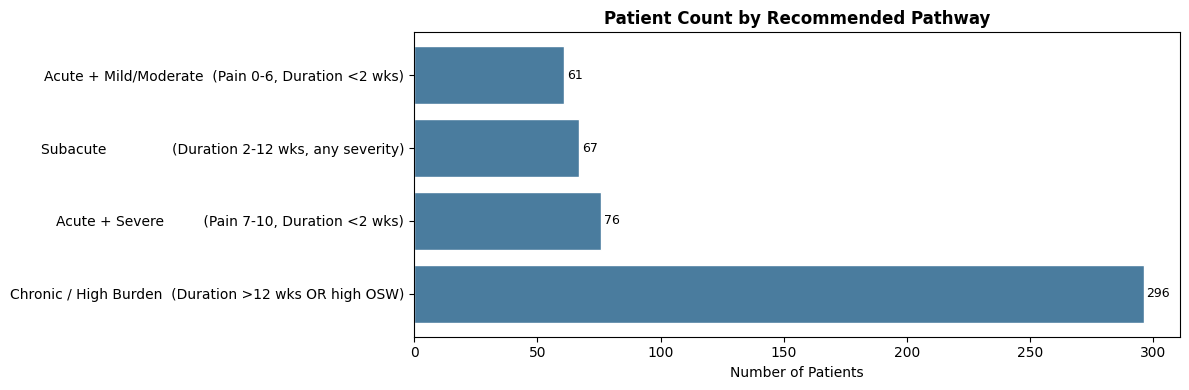

In [51]:
# Pathway distribution chart

pathway_counts = patients["recommended_pathway"].value_counts()
labels = [PATHWAY_LABELS[p] for p in pathway_counts.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(labels, pathway_counts.values, color="#4a7c9e", edgecolor="white")
ax.set_title("Patient Count by Recommended Pathway", fontweight="bold")
ax.set_xlabel("Number of Patients")
for i, v in enumerate(pathway_counts.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("pathway_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

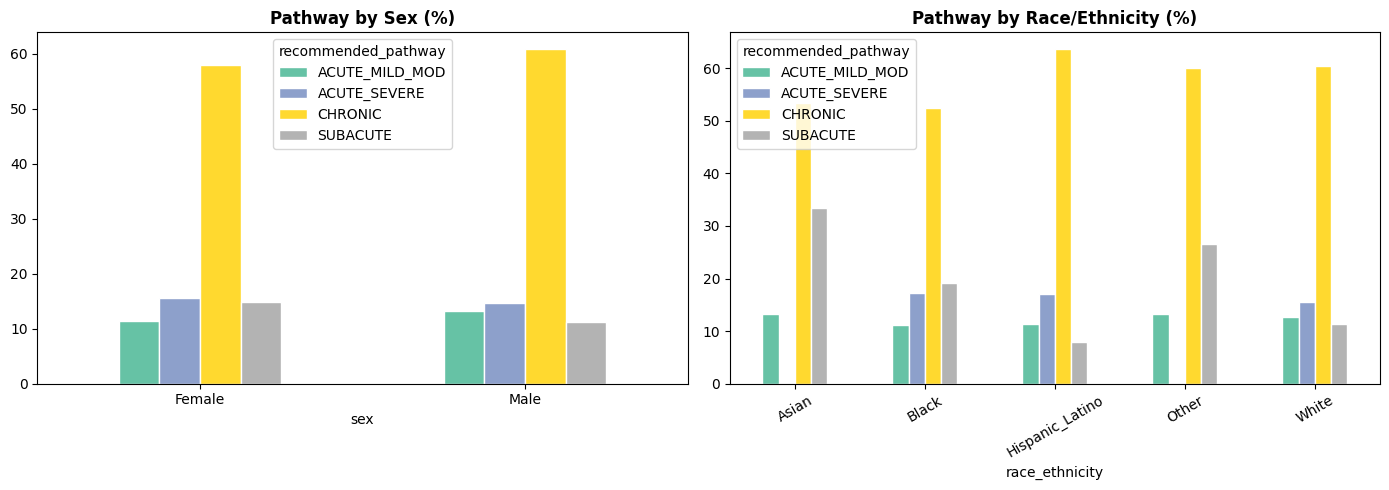

In [52]:
# Equity check

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(patients["sex"], patients["recommended_pathway"], normalize="index").mul(100).plot(
    kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Pathway by Sex (%)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(patients["race_ethnicity"], patients["recommended_pathway"], normalize="index").mul(100).plot(
    kind="bar", ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("Pathway by Race/Ethnicity (%)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("equity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# Join Exercises to Patients

pathway_rows = []
for pathway, codes in PATHWAY_EXERCISES.items():
    for code in codes:
        pathway_rows.append({"recommended_pathway": pathway, "Category_Code": code})
pathway_exercise_map = pd.DataFrame(pathway_rows)

patient_exercises = (
    patients[["patient_id","recommended_pathway","pathway_label"]]
    .merge(pathway_exercise_map, on="recommended_pathway", how="left")
    .merge(
        exercises[["Exercise_ID","Exercise name","Category_Code","Exercise group",
                   "Progression_Level","Difficulty","Equipment_Needed",
                   "Contraindications","Exercise description"]],
        on="Category_Code", how="left"
    )
    .sort_values(["patient_id","Category_Code","Progression_Level"])
)

print(f"Total patient-exercise rows : {len(patient_exercises)}")
first_id = patient_exercises["patient_id"].iloc[0]
print(f"\nSample — Patient {first_id}:")
print(
    patient_exercises[patient_exercises["patient_id"]==first_id][
        ["recommended_pathway","Exercise group","Exercise_ID","Exercise name","Progression_Level","Difficulty"]
    ].to_string(index=False)
)

Total patient-exercise rows : 27497

Sample — Patient P001:
recommended_pathway                                 Exercise group Exercise_ID                                        Exercise name  Progression_Level   Difficulty
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-001                        DOUBLE KNEE TO CHEST STRETCH                   1        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-002                 Double knee to chest with swiss ball                  2     Advanced
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-003                            Double Knee Chest Stretch                  3        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-004                                 SEATED TRUNK FLEXION                  4        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-005                                Seated lum

In [54]:
# Export to BigQuery

from google.cloud.bigquery import LoadJobConfig, WriteDisposition

job_config = LoadJobConfig(write_disposition=WriteDisposition.WRITE_TRUNCATE, autodetect=True)
job = client.load_table_from_dataframe(
    patients, f"{PROJECT_ID}.{DATASET}.patient_pathways", job_config=job_config
)
job.result()
print(f"Exported {len(patients)} labelled patients → patient_pathways")

Exported 500 labelled patients → patient_pathways


# Export Note

The `patient_pathways` table exported to BigQuery contains rule-assigned
pathway labels, not clinically validated predictions. These labels serve as:
1. Training labels for the logistic regression model in Notebook 04
2. The basis for exercise recommendations joined in Notebook 05

Downstream use should be understood as rule-replication outputs.
Clinician validation is planned for Phase 2.

Decision Tree accuracy on full dataset: 100.0%
(Visualisation only — trained on rule-generated labels, not clinical outcomes)
(Tree resolves at depth 3; threshold 'Duration <= 1.95' equals '< 2 weeks')


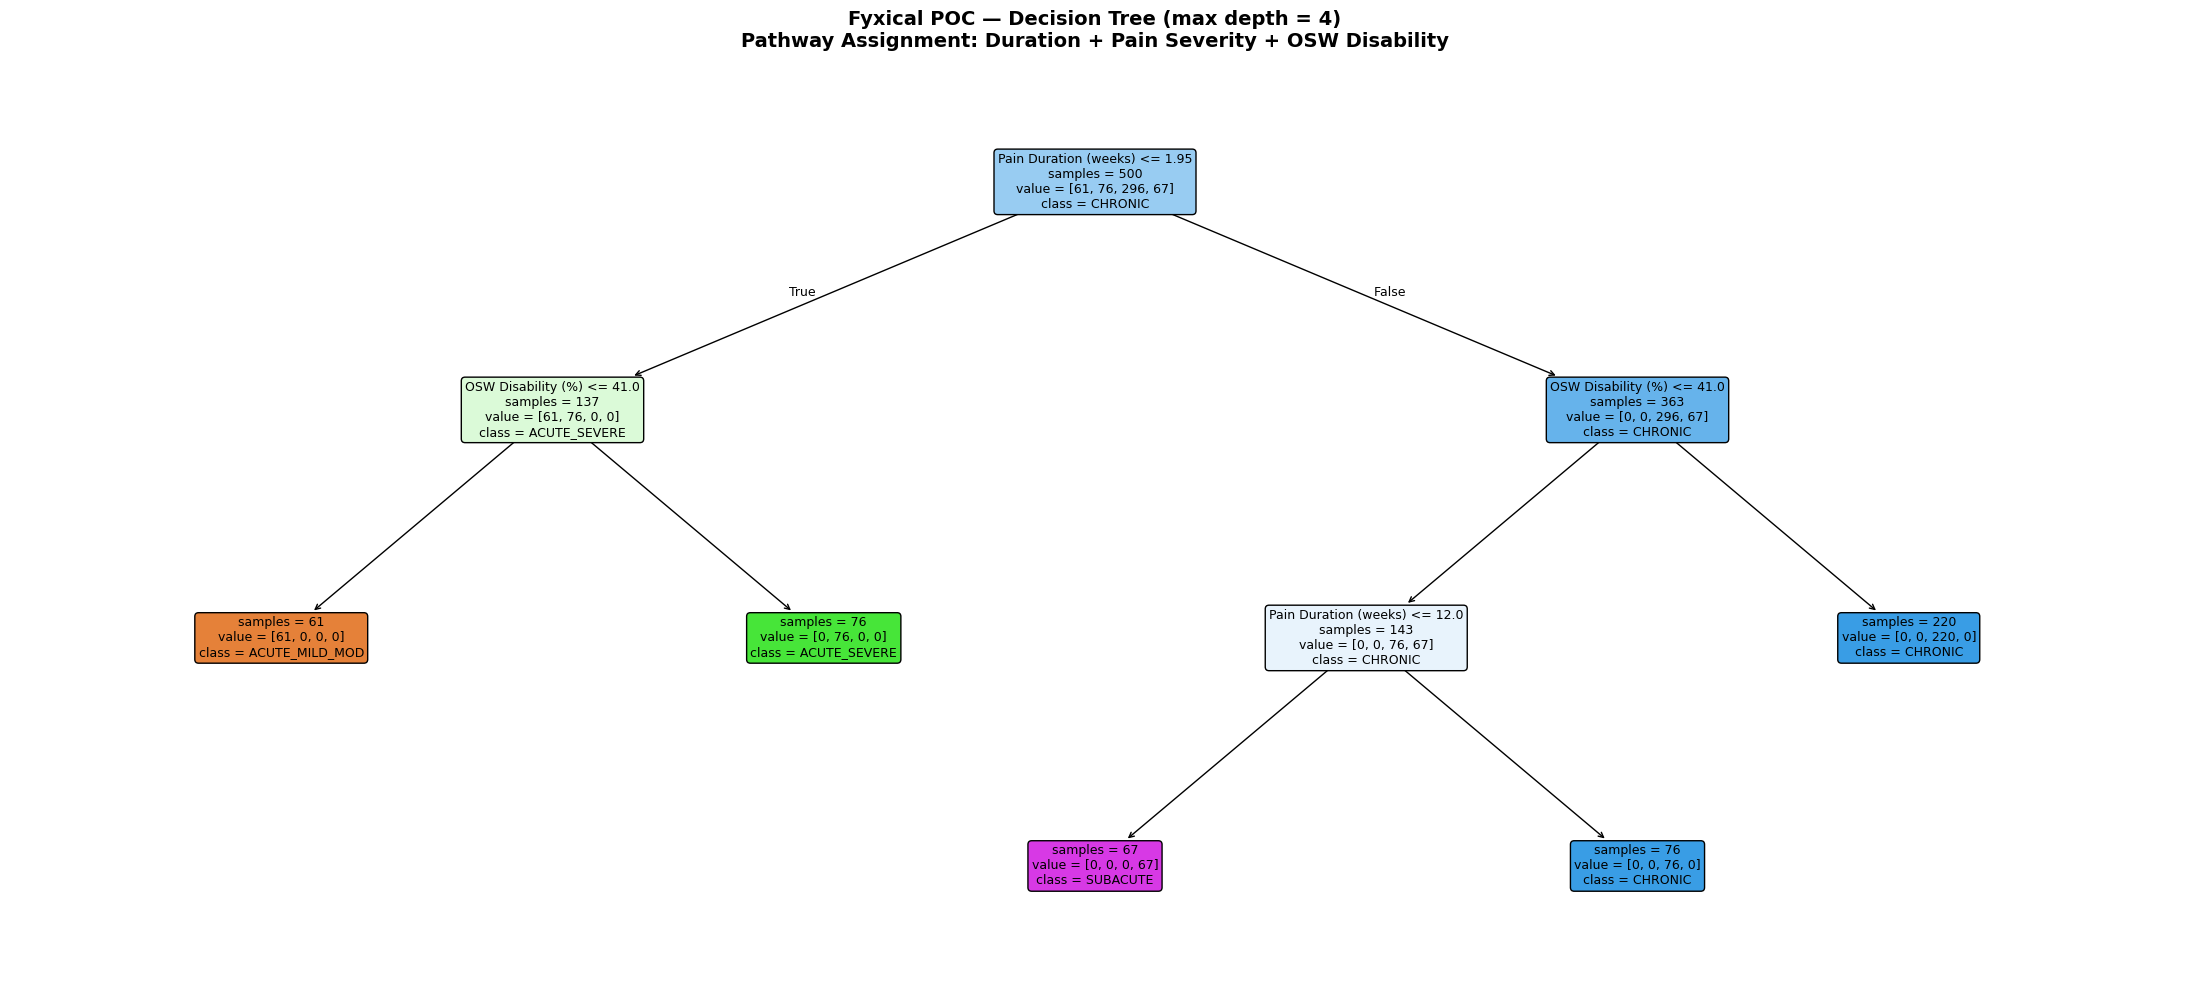

In [55]:
# Decision Tree visual

from sklearn.tree import DecisionTreeClassifier, plot_tree

feature_cols          = ["pain_duration_weeks", "pain_severity_score_0_10", "osw_baseline_percent_disability"]
feature_display_names = ["Pain Duration (weeks)", "Pain Score (0-10)", "OSW Disability (%)"]

X_tree = patients[feature_cols].values
y_tree = patients["recommended_pathway"].values

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_tree, y_tree)

print(f"Decision Tree accuracy on full dataset: {dt.score(X_tree, y_tree)*100:.1f}%")
print("(Visualisation only — trained on rule-generated labels, not clinical outcomes)")
print("(Tree resolves at depth 3; threshold 'Duration <= 1.95' equals '< 2 weeks')")

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_display_names,
    class_names=dt.classes_,
    filled=True, rounded=True, fontsize=9,
    ax=ax, impurity=False, proportion=False,
)
ax.set_title(
    "Fyxical POC — Decision Tree (max depth = 4)\n"
    "Pathway Assignment: Duration + Pain Severity + OSW Disability",
    fontsize=14, fontweight="bold", pad=15
)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()